## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

sns.set_style('darkgrid')
print("All imports done!")

All imports done!


## Load featured dataset

In [2]:
# ── Load featured_transactions.csv ────────────────────────
# 80 columns: 79 features + Is Laundering
# This is the source of truth for all models

df_feat = pd.read_csv('featured/featured_transactions.csv')

print(f"Shape   : {df_feat.shape}")
print(f"Fraud   : {df_feat['Is Laundering'].sum():,}")
print(f"Normal  : {(df_feat['Is Laundering']==0).sum():,}")

y_all = df_feat['Is Laundering'].values

# ── Use encoded account IDs as identifiers ─────────────────
# Your featured CSV has NO original account strings
# Sender_Account_Encoded and Receiver_Account_Encoded
# are the only account identifiers available
# We use them as the join key for all score mappings

SENDER_COL   = 'Sender_Account_Encoded'
RECEIVER_COL = 'Receiver_Account_Encoded'

print(f"\nSender column   : {SENDER_COL}")
print(f"Receiver column : {RECEIVER_COL}")
print(f"Unique senders  : {df_feat[SENDER_COL].nunique():,}")

Shape   : (5078336, 80)
Fraud   : 5,177
Normal  : 5,073,159

Sender column   : Sender_Account_Encoded
Receiver column : Receiver_Account_Encoded
Unique senders  : 496,995


## Load XGBoost model and generate scores for all 5M rows

In [3]:
# ── Load XGBoost model ────────────────────────────────────
model_xgb = joblib.load('models/xgboost_model.pkl')
scaler    = joblib.load('models/scaler.pkl')

print(f"XGBoost loaded!")
print(f"Features expected: {model_xgb.n_features_in_}")

# Get exact feature list model was trained on
XGB_FEATURES = list(model_xgb.feature_names_in_)
print(f"\nXGBoost feature list:")
for i, f in enumerate(XGB_FEATURES, 1):
    print(f"  {i:2}. {f}")

# ── Check all features exist in df_feat ───────────────────
missing = [f for f in XGB_FEATURES if f not in df_feat.columns]
print(f"\nMissing from featured dataset: {missing}")

# ── Build feature matrix for all 5M rows ──────────────────
# Add any missing derived columns
df_work = df_feat.copy()

if 'Amount_Received_Log' not in df_work.columns:
    if 'receiver_total_amount_received' in df_work.columns:
        df_work['Amount_Received_Log'] = np.log1p(
            df_work['receiver_total_amount_received'].abs()
        )
    else:
        df_work['Amount_Received_Log'] = 0.0
    print("Created: Amount_Received_Log")

if 'Amount_Diff_Log' not in df_work.columns:
    if 'Amount_Paid_Log' in df_work.columns and 'Amount_Received_Log' in df_work.columns:
        df_work['Amount_Diff_Log'] = np.log1p(
            np.abs(df_work['Amount_Paid_Log'] - df_work['Amount_Received_Log'])
        )
    else:
        df_work['Amount_Diff_Log'] = 0.0
    print("Created: Amount_Diff_Log")

# Re-check missing features
missing = [f for f in XGB_FEATURES if f not in df_work.columns]
if missing:
    print(f"Still missing: {missing}")
    for f in missing:
        df_work[f] = 0.0
    print("Filled with 0.0")

# ── Select and validate ────────────────────────────────────
X_xgb = df_work[XGB_FEATURES].fillna(0).astype(np.float32)
print(f"\nX_xgb shape : {X_xgb.shape}")
print(f"NaN count   : {X_xgb.isna().sum().sum()}")
print(f"Inf count   : {np.isinf(X_xgb.values).sum()}")

XGBoost loaded!
Features expected: 30

XGBoost feature list:
   1. Hour
   2. Day
   3. DayOfWeek
   4. IsWeekend
   5. Sender Bank ID
   6. Receiver Bank ID
   7. is_cross_bank
   8. is_self_transfer
   9. Amount_Paid_Log
  10. Amount_Received_Log
  11. Amount_Diff_Log
  12. amount_vs_account_median
  13. Payment_Currency_Encoded
  14. Receiving_Currency_Encoded
  15. is_currency_mismatch
  16. is_amount_outlier_iqr
  17. is_amount_outlier_zscore
  18. is_account_level_outlier
  19. outlier_score
  20. is_outlier
  21. txn_count_per_sender_hour
  22. txn_count_per_sender_day
  23. is_high_velocity
  24. fmt_ACH
  25. fmt_Bitcoin
  26. fmt_Cash
  27. fmt_Cheque
  28. fmt_Credit Card
  29. fmt_Reinvestment
  30. fmt_Wire

Missing from featured dataset: [np.str_('Amount_Received_Log'), np.str_('Amount_Diff_Log')]
Created: Amount_Received_Log
Created: Amount_Diff_Log

X_xgb shape : (5078336, 30)
NaN count   : 0
Inf count   : 0


## Score all 5M transactions with XGBoost

In [4]:
# ── Score in batches to avoid memory issues ───────────────
BATCH_SIZE = 200_000
n_total    = len(X_xgb)
xgb_scores = []

print(f"Scoring {n_total:,} transactions in batches of {BATCH_SIZE:,}...")

for start in range(0, n_total, BATCH_SIZE):
    end   = min(start + BATCH_SIZE, n_total)
    batch = X_xgb.iloc[start:end]

    # XGBoost trained WITHOUT scaler in your notebook
    # (your XGBoost notebook used raw featured columns)
    # If it was trained WITH scaler, uncomment next line:
    # batch = scaler.transform(batch)

    probs = model_xgb.predict_proba(batch)[:, 1]
    xgb_scores.extend(probs)

    pct = end / n_total * 100
    if start % 1_000_000 == 0:
        print(f"  {pct:.0f}% done...")

xgb_scores = np.array(xgb_scores, dtype=np.float32)

print(f"\nXGBoost scoring complete!")
print(f"Total scored      : {len(xgb_scores):,}")
print(f"Mean score(fraud) : {xgb_scores[y_all==1].mean():.4f}")
print(f"Mean score(normal): {xgb_scores[y_all==0].mean():.4f}")
print(f"Max score         : {xgb_scores.max():.4f}")

# Quick AUC check
auc_xgb = roc_auc_score(y_all, xgb_scores)
print(f"AUC-ROC (all 5M)  : {auc_xgb:.4f}")

Scoring 5,078,336 transactions in batches of 200,000...
  4% done...
  24% done...
  43% done...
  63% done...
  83% done...
  100% done...

XGBoost scoring complete!
Total scored      : 5,078,336
Mean score(fraud) : 0.0150
Mean score(normal): 0.0040
Max score         : 0.8001
AUC-ROC (all 5M)  : 0.9110


## Score all 5M transactions with XGBoost

In [5]:
# ── Score in batches to avoid memory issues ───────────────
BATCH_SIZE = 200_000
n_total    = len(X_xgb)
xgb_scores = []

print(f"Scoring {n_total:,} transactions in batches of {BATCH_SIZE:,}...")

for start in range(0, n_total, BATCH_SIZE):
    end   = min(start + BATCH_SIZE, n_total)
    batch = X_xgb.iloc[start:end]

    # XGBoost trained WITHOUT scaler in your notebook
    # (your XGBoost notebook used raw featured columns)
    # If it was trained WITH scaler, uncomment next line:
    # batch = scaler.transform(batch)

    probs = model_xgb.predict_proba(batch)[:, 1]
    xgb_scores.extend(probs)

    pct = end / n_total * 100
    if start % 1_000_000 == 0:
        print(f"  {pct:.0f}% done...")

xgb_scores = np.array(xgb_scores, dtype=np.float32)

print(f"\nXGBoost scoring complete!")
print(f"Total scored      : {len(xgb_scores):,}")
print(f"Mean score(fraud) : {xgb_scores[y_all==1].mean():.4f}")
print(f"Mean score(normal): {xgb_scores[y_all==0].mean():.4f}")
print(f"Max score         : {xgb_scores.max():.4f}")

# Quick AUC check
auc_xgb = roc_auc_score(y_all, xgb_scores)
print(f"AUC-ROC (all 5M)  : {auc_xgb:.4f}")

Scoring 5,078,336 transactions in batches of 200,000...
  4% done...
  24% done...
  43% done...
  63% done...
  83% done...
  100% done...

XGBoost scoring complete!
Total scored      : 5,078,336
Mean score(fraud) : 0.0150
Mean score(normal): 0.0040
Max score         : 0.8001
AUC-ROC (all 5M)  : 0.9110


## Load all other model scores

In [6]:
print("Loading all model scores...")

# ── LSTM scores ───────────────────────────────────────────
lstm_scores_raw = np.zeros(len(df_feat), dtype=np.float32)
has_lstm        = False

try:
    lstm_df = pd.read_csv('results/lstm_scores.csv')
    print(f"LSTM file loaded : {lstm_df.shape}")
    print(f"LSTM columns     : {lstm_df.columns.tolist()}")

    # Find score column
    lstm_score_col = None
    for col in ['lstm_fraud_score','lstm_anomaly_score','lstm_score']:
        if col in lstm_df.columns:
            lstm_score_col = col
            break

    # Find account/index column
    lstm_idx_col = None
    for col in ['Sender_Account_Encoded','account_id','Sender Account']:
        if col in lstm_df.columns:
            lstm_idx_col = col
            break

    print(f"LSTM score col   : {lstm_score_col}")
    print(f"LSTM index col   : {lstm_idx_col}")

    if lstm_score_col:
        if lstm_idx_col and lstm_idx_col in df_feat.columns:
            # Map by encoded account ID
            lstm_map = lstm_df.groupby(lstm_idx_col)[lstm_score_col].max()
            mapped   = df_feat[SENDER_COL].map(lstm_map).fillna(0).values
            lstm_scores_raw = mapped.astype(np.float32)
            n_mapped = (lstm_scores_raw > 0).sum()
            print(f"LSTM mapped      : {n_mapped:,} rows ({n_mapped/len(df_feat)*100:.1f}%)")
        else:
            # Use positional assignment for same-length files
            if len(lstm_df) == len(df_feat):
                lstm_scores_raw = lstm_df[lstm_score_col].fillna(0).values.astype(np.float32)
                print(f"LSTM positional  : {(lstm_scores_raw>0).sum():,} rows")
            else:
                # Use as account-level lookup with index
                lstm_by_idx = lstm_df[lstm_score_col].values
                valid_len   = min(len(lstm_by_idx), len(df_feat))
                lstm_scores_raw[:valid_len] = lstm_by_idx[:valid_len].astype(np.float32)

        has_lstm = lstm_scores_raw.max() > 0
        print(f"LSTM has signal  : {has_lstm}")
        if has_lstm:
            print(f"LSTM mean(fraud) : {lstm_scores_raw[y_all==1].mean():.4f}")

except Exception as e:
    print(f"LSTM not loaded  : {e}")


# ── Autoencoder scores ────────────────────────────────────
ae_scores_raw = np.zeros(len(df_feat), dtype=np.float32)
has_ae        = False

try:
    ae_df = pd.read_csv('results/ae_scores.csv')
    print(f"\nAE file loaded   : {ae_df.shape}")
    print(f"AE columns       : {ae_df.columns.tolist()}")

    ae_score_col = None
    for col in ['ae_anomaly_score','ae_score','reconstruction_error']:
        if col in ae_df.columns:
            ae_score_col = col
            break

    ae_idx_col = None
    for col in ['Sender_Account_Encoded','Sender Account','account_id']:
        if col in ae_df.columns:
            ae_idx_col = col
            break

    print(f"AE score col     : {ae_score_col}")
    print(f"AE index col     : {ae_idx_col}")

    if ae_score_col:
        if ae_idx_col and ae_idx_col in df_feat.columns:
            ae_map = ae_df.groupby(ae_idx_col)[ae_score_col].max()
            mapped = df_feat[SENDER_COL].map(ae_map).fillna(0).values
            ae_scores_raw = mapped.astype(np.float32)
        elif len(ae_df) == len(df_feat):
            ae_scores_raw = ae_df[ae_score_col].fillna(0).values.astype(np.float32)
        else:
            valid_len = min(len(ae_df), len(df_feat))
            ae_scores_raw[:valid_len] = ae_df[ae_score_col].values[:valid_len].astype(np.float32)

        # Normalise AE scores to 0-1
        ae_max = ae_scores_raw.max()
        ae_min = ae_scores_raw.min()
        if ae_max > ae_min:
            ae_scores_raw = (ae_scores_raw - ae_min) / (ae_max - ae_min + 1e-9)

        has_ae = ae_scores_raw.max() > 0
        print(f"AE has signal    : {has_ae}")
        if has_ae:
            print(f"AE mean(fraud)   : {ae_scores_raw[y_all==1].mean():.4f}")

except Exception as e:
    print(f"\nAE not loaded    : {e}")


# ── CNN scores ────────────────────────────────────────────
cnn_scores_raw = np.zeros(len(df_feat), dtype=np.float32)
has_cnn        = False

try:
    cnn_df = pd.read_csv('results/cnn_scores.csv')
    print(f"\nCNN file loaded  : {cnn_df.shape}")
    print(f"CNN columns      : {cnn_df.columns.tolist()}")

    cnn_score_col = None
    for col in ['cnn_fraud_score','cnn_score','fraud_score']:
        if col in cnn_df.columns:
            cnn_score_col = col
            break

    cnn_idx_col = None
    for col in ['account_id','Sender_Account_Encoded','Sender Account']:
        if col in cnn_df.columns:
            cnn_idx_col = col
            break

    print(f"CNN score col    : {cnn_score_col}")
    print(f"CNN index col    : {cnn_idx_col}")

    if cnn_score_col:
        if cnn_idx_col and cnn_idx_col in df_feat.columns:
            cnn_map = cnn_df.groupby(cnn_idx_col)[cnn_score_col].max()
            mapped  = df_feat[SENDER_COL].map(cnn_map).fillna(0).values
            cnn_scores_raw = mapped.astype(np.float32)
        elif cnn_idx_col == 'account_id':
            # account_id matches Sender_Account_Encoded
            cnn_map = cnn_df.groupby('account_id')[cnn_score_col].max()
            mapped  = df_feat[SENDER_COL].map(cnn_map).fillna(0).values
            cnn_scores_raw = mapped.astype(np.float32)
        elif len(cnn_df) == len(df_feat):
            cnn_scores_raw = cnn_df[cnn_score_col].fillna(0).values.astype(np.float32)

        has_cnn = cnn_scores_raw.max() > 0
        print(f"CNN has signal   : {has_cnn}")
        if has_cnn:
            print(f"CNN mean(fraud)  : {cnn_scores_raw[y_all==1].mean():.4f}")

except Exception as e:
    print(f"\nCNN not loaded   : {e}")


# ── Graph scores ──────────────────────────────────────────
graph_scores_raw = np.zeros(len(df_feat), dtype=np.float32)
has_graph        = False

try:
    graph_df = pd.read_csv('results/graph_scores.csv')
    print(f"\nGraph file loaded: {graph_df.shape}")
    print(f"Graph columns    : {graph_df.columns.tolist()}")

    graph_score_col = None
    for col in ['graph_risk_score','graph_score','risk_score']:
        if col in graph_df.columns:
            graph_score_col = col
            break

    graph_idx_col = None
    for col in ['Sender_Account_Encoded','Sender Account','account_id']:
        if col in graph_df.columns:
            graph_idx_col = col
            break

    print(f"Graph score col  : {graph_score_col}")
    print(f"Graph index col  : {graph_idx_col}")

    if graph_score_col:
        if graph_idx_col and graph_idx_col in df_feat.columns:
            gmap   = graph_df.groupby(graph_idx_col)[graph_score_col].max()
            mapped = df_feat[SENDER_COL].map(gmap).fillna(0).values
            graph_scores_raw = mapped.astype(np.float32)
        elif len(graph_df) == len(df_feat):
            graph_scores_raw = graph_df[graph_score_col].fillna(0).values.astype(np.float32)

        # Normalise to 0-1
        g_max = graph_scores_raw.max()
        if g_max > 0:
            graph_scores_raw = graph_scores_raw / g_max

        has_graph = graph_scores_raw.max() > 0
        print(f"Graph has signal : {has_graph}")
        if has_graph:
            print(f"Graph mean(fraud): {graph_scores_raw[y_all==1].mean():.4f}")

except Exception as e:
    print(f"\nGraph not loaded : {e}")


# ── Composite risk score from featured dataset ────────────
composite_raw = np.zeros(len(df_feat), dtype=np.float32)
has_composite = False

if 'composite_risk_score' in df_feat.columns:
    cs = df_feat['composite_risk_score'].fillna(0).values
    cs_max = cs.max()
    if cs_max > 0:
        composite_raw = (cs / cs_max).astype(np.float32)
        has_composite = True
        print(f"\nComposite loaded : max={cs_max}, coverage={(composite_raw>0).sum():,}")

print(f"\n{'='*55}")
print(f"SCORE COVERAGE SUMMARY")
print(f"{'='*55}")
print(f"  XGBoost   : {(xgb_scores>0).sum():>10,} ({(xgb_scores>0).mean()*100:.1f}%)")
print(f"  LSTM      : {(lstm_scores_raw>0).sum():>10,} ({(lstm_scores_raw>0).mean()*100:.1f}%)")
print(f"  AE        : {(ae_scores_raw>0).sum():>10,} ({(ae_scores_raw>0).mean()*100:.1f}%)")
print(f"  CNN       : {(cnn_scores_raw>0).sum():>10,} ({(cnn_scores_raw>0).mean()*100:.1f}%)")
print(f"  Graph     : {(graph_scores_raw>0).sum():>10,} ({(graph_scores_raw>0).mean()*100:.1f}%)")
print(f"  Composite : {(composite_raw>0).sum():>10,} ({(composite_raw>0).mean()*100:.1f}%)")

Loading all model scores...
LSTM not loaded  : [Errno 2] No such file or directory: 'results/lstm_scores.csv'

AE not loaded    : [Errno 2] No such file or directory: 'results/ae_scores.csv'

CNN file loaded  : (710679, 2)
CNN columns      : ['account_id', 'cnn_fraud_score']
CNN score col    : cnn_fraud_score
CNN index col    : account_id
CNN has signal   : True
CNN mean(fraud)  : 0.0269

Graph not loaded : [Errno 2] No such file or directory: 'results/graph_scores.csv'

Composite loaded : max=10, coverage=5,060,889

SCORE COVERAGE SUMMARY
  XGBoost   :  5,078,336 (100.0%)
  LSTM      :          0 (0.0%)
  AE        :          0 (0.0%)
  CNN       :    168,672 (3.3%)
  Graph     :          0 (0.0%)
  Composite :  5,060,889 (99.7%)


## Build master risk DataFrame

In [7]:
# ── Build clean master DataFrame ──────────────────────────
risk_df = pd.DataFrame({
    'Is Laundering'          : y_all,
    'Sender_Account_Encoded' : df_feat[SENDER_COL].values,
    'xgb_score'              : xgb_scores,
    'lstm_score'             : lstm_scores_raw,
    'ae_score'               : ae_scores_raw,
    'cnn_score'              : cnn_scores_raw,
    'graph_score'            : graph_scores_raw,
    'composite_score'        : composite_raw,
})

# Add Amount Paid for display
if 'Amount_Paid_Log' in df_feat.columns:
    risk_df['Amount_Paid_Log'] = df_feat['Amount_Paid_Log'].values

print(f"Master risk DataFrame: {risk_df.shape}")
print(f"\nScore ranges:")
for col in ['xgb_score','lstm_score','ae_score','cnn_score','graph_score','composite_score']:
    vals = risk_df[col].values
    print(f"  {col:20}: min={vals.min():.4f} max={vals.max():.4f} mean={vals.mean():.4f}")

Master risk DataFrame: (5078336, 9)

Score ranges:
  xgb_score           : min=0.0002 max=0.8001 mean=0.0041
  lstm_score          : min=0.0000 max=0.0000 mean=0.0000
  ae_score            : min=0.0000 max=0.0000 mean=0.0000
  cnn_score           : min=0.0000 max=0.5725 mean=0.0190
  graph_score         : min=0.0000 max=0.0000 mean=0.0000
  composite_score     : min=0.0000 max=1.0000 mean=0.2636


## Weighted ensemble scoring

In [8]:
# ════════════════════════════════════════════════════════
# WEIGHTED ENSEMBLE
# ════════════════════════════════════════════════════════
# Weights reflect actual AUC-PR from your notebooks:
# XGBoost   : highest weight — best AUC-PR 0.2379
# Composite : built from 17 hand-crafted signals
# Others    : weighted by whether they have signal
# ════════════════════════════════════════════════════════

BASE_WEIGHTS = {
    'xgb_score'      : 0.50,
    'lstm_score'     : 0.12,
    'ae_score'       : 0.10,
    'cnn_score'      : 0.10,
    'graph_score'    : 0.10,
    'composite_score': 0.08,
}

# Check which scores have actual signal
active_cols = {}
for col, w in BASE_WEIGHTS.items():
    has_signal = (risk_df[col] > 0).sum() > 1000
    active_cols[col] = has_signal

print("Model availability:")
for col, active in active_cols.items():
    status = "ACTIVE" if active else "NO SIGNAL — weight redistributed"
    print(f"  {col:20}: {status}")

# Redistribute inactive weights to xgb_score
inactive_weight = sum(
    w for col, w in BASE_WEIGHTS.items()
    if not active_cols[col]
)

WEIGHTS = {}
for col, w in BASE_WEIGHTS.items():
    if active_cols[col]:
        # Active models keep weight + proportional share of inactive
        total_active_w = sum(
            bw for c, bw in BASE_WEIGHTS.items()
            if active_cols[c]
        )
        WEIGHTS[col] = w + inactive_weight * (w / total_active_w)
    else:
        WEIGHTS[col] = 0.0

# Normalise weights to exactly 1.0
total_w = sum(WEIGHTS.values())
WEIGHTS = {col: w/total_w for col, w in WEIGHTS.items()}

print(f"\nFinal weights:")
for col, w in WEIGHTS.items():
    if w > 0:
        print(f"  {col:20}: {w:.4f} ({w*100:.1f}%)")
print(f"  Weight sum           : {sum(WEIGHTS.values()):.6f}")

# ── Compute ensemble score ────────────────────────────────
risk_df['ensemble_raw'] = sum(
    WEIGHTS[col] * risk_df[col]
    for col in WEIGHTS
)

# ── Scale to 0-100 ────────────────────────────────────────
e_min = risk_df['ensemble_raw'].min()
e_max = risk_df['ensemble_raw'].max()
risk_df['risk_score_100'] = (
    (risk_df['ensemble_raw'] - e_min) / (e_max - e_min + 1e-9)
) * 100

print(f"\nEnsemble score stats:")
print(f"  Min  : {risk_df['risk_score_100'].min():.4f}")
print(f"  Max  : {risk_df['risk_score_100'].max():.4f}")
print(f"  Mean : {risk_df['risk_score_100'].mean():.4f}")
print(f"  Fraud mean  : {risk_df.loc[y_all==1,'risk_score_100'].mean():.4f}")
print(f"  Normal mean : {risk_df.loc[y_all==0,'risk_score_100'].mean():.4f}")

Model availability:
  xgb_score           : ACTIVE
  lstm_score          : NO SIGNAL — weight redistributed
  ae_score            : NO SIGNAL — weight redistributed
  cnn_score           : ACTIVE
  graph_score         : NO SIGNAL — weight redistributed
  composite_score     : ACTIVE

Final weights:
  xgb_score           : 0.7353 (73.5%)
  cnn_score           : 0.1471 (14.7%)
  composite_score     : 0.1176 (11.8%)
  Weight sum           : 1.000000

Ensemble score stats:
  Min  : 0.0000
  Max  : 100.0000
  Mean : 5.8514
  Fraud mean  : 8.2196
  Normal mean : 5.8490


## Calibrate thresholds from actual score distribution

In [9]:
# ════════════════════════════════════════════════════════
# THRESHOLD CALIBRATION
# ════════════════════════════════════════════════════════
# We do NOT use fixed 30/50/70 thresholds
# We calibrate from actual score distribution so that:
#   CRITICAL = top 0.5% of all transactions
#   HIGH     = top 2.5% of all transactions
#   MEDIUM   = top 10% of all transactions
#   LOW      = everything else
#
# This gives manageable alert volumes regardless of
# what the raw score distribution looks like
# ════════════════════════════════════════════════════════

scores = risk_df['risk_score_100'].values

# Percentile-based thresholds
THRESH_CRITICAL = np.percentile(scores, 99.5)   # top 0.5%
THRESH_HIGH     = np.percentile(scores, 97.5)   # top 2.5%
THRESH_MEDIUM   = np.percentile(scores, 90.0)   # top 10%

print(f"Calibrated thresholds from actual score distribution:")
print(f"  CRITICAL (top 0.5%) : score >= {THRESH_CRITICAL:.2f}")
print(f"  HIGH     (top 2.5%) : score >= {THRESH_HIGH:.2f}")
print(f"  MEDIUM   (top 10%)  : score >= {THRESH_MEDIUM:.2f}")
print(f"  LOW                 : everything else")

def classify_risk(score):
    if score >= THRESH_CRITICAL: return 'CRITICAL'
    elif score >= THRESH_HIGH:   return 'HIGH'
    elif score >= THRESH_MEDIUM: return 'MEDIUM'
    else:                        return 'LOW'

risk_df['risk_level'] = risk_df['risk_score_100'].apply(classify_risk)

print(f"\nRisk level distribution:")
for lvl in ['LOW','MEDIUM','HIGH','CRITICAL']:
    sub  = risk_df[risk_df['risk_level']==lvl]
    rate = sub['Is Laundering'].mean() * 100
    n    = len(sub)
    bar  = '█' * int(rate * 8)
    print(f"  {lvl:8}: {n:>10,} txns | fraud rate: {rate:.4f}%  {bar}")

print(f"\nAlerts (HIGH + CRITICAL): {(risk_df['risk_level'].isin(['HIGH','CRITICAL'])).sum():,}")
print(f"Alert rate              : {(risk_df['risk_level'].isin(['HIGH','CRITICAL'])).mean()*100:.2f}%")

Calibrated thresholds from actual score distribution:
  CRITICAL (top 0.5%) : score >= 27.00
  HIGH     (top 2.5%) : score >= 23.66
  MEDIUM   (top 10%)  : score >= 10.13
  LOW                 : everything else

Risk level distribution:
  LOW     :  4,570,491 txns | fraud rate: 0.0854%  
  MEDIUM  :    378,721 txns | fraud rate: 0.2844%  ██
  HIGH    :    103,727 txns | fraud rate: 0.1523%  █
  CRITICAL:     25,397 txns | fraud rate: 0.1614%  █

Alerts (HIGH + CRITICAL): 129,124
Alert rate              : 2.54%


## Fraud capture analysis

In [10]:
# ── Fraud capture by risk level ───────────────────────────
total_fraud = int(y_all.sum())
print(f"Total fraud in dataset: {total_fraud:,}")

print(f"\nFraud captured by risk level:")
cumulative = 0
for lvl in ['CRITICAL','HIGH','MEDIUM','LOW']:
    sub       = risk_df[(risk_df['risk_level']==lvl) & (risk_df['Is Laundering']==1)]
    n_fraud   = len(sub)
    cumulative += n_fraud
    pct       = n_fraud / total_fraud * 100
    print(f"  {lvl:8}: {n_fraud:>5,} fraud ({pct:.1f}%) | cumulative: {cumulative:,} ({cumulative/total_fraud*100:.1f}%)")

# ── Generate alerts ───────────────────────────────────────
alerts = risk_df[
    risk_df['risk_level'].isin(['CRITICAL','HIGH'])
].copy().sort_values('risk_score_100', ascending=False)

alerts['alert_id']     = [f"AML-{i+1:06d}" for i in range(len(alerts))]
alerts['alert_status'] = 'PENDING_REVIEW'

fraud_in_alerts = int(alerts['Is Laundering'].sum())
capture_rate    = fraud_in_alerts / total_fraud * 100
alert_rate      = len(alerts) / len(risk_df) * 100

print(f"\n{'='*55}")
print(f"ALERT SUMMARY")
print(f"{'='*55}")
print(f"  Total alerts     : {len(alerts):,}")
print(f"  Alert rate       : {alert_rate:.2f}%")
print(f"  Fraud captured   : {fraud_in_alerts:,} / {total_fraud:,}")
print(f"  Capture rate     : {capture_rate:.2f}%")

print(f"\nTop 10 highest risk alerts:")
display_cols = ['alert_id','risk_level','risk_score_100','xgb_score','Is Laundering']
if 'Amount_Paid_Log' in alerts.columns:
    display_cols.insert(4, 'Amount_Paid_Log')
print(alerts[display_cols].head(10).to_string(index=False))

Total fraud in dataset: 5,177

Fraud captured by risk level:
  CRITICAL:    41 fraud (0.8%) | cumulative: 41 (0.8%)
  HIGH    :   158 fraud (3.1%) | cumulative: 199 (3.8%)
  MEDIUM  : 1,077 fraud (20.8%) | cumulative: 1,276 (24.6%)
  LOW     : 3,901 fraud (75.4%) | cumulative: 5,177 (100.0%)

ALERT SUMMARY
  Total alerts     : 129,124
  Alert rate       : 2.54%
  Fraud captured   : 199 / 5,177
  Capture rate     : 3.84%

Top 10 highest risk alerts:
  alert_id risk_level  risk_score_100  xgb_score  Amount_Paid_Log  Is Laundering
AML-000001   CRITICAL      100.000000   0.785846         4.951805              0
AML-000002   CRITICAL       99.790161   0.800063         5.848691              0
AML-000003   CRITICAL       99.790161   0.800063         5.794202              0
AML-000004   CRITICAL       99.357689   0.796389         5.468482              0
AML-000005   CRITICAL       97.906761   0.800063         5.814101              0
AML-000006   CRITICAL       97.842140   0.751514         6.01

## Comprehensive visualization

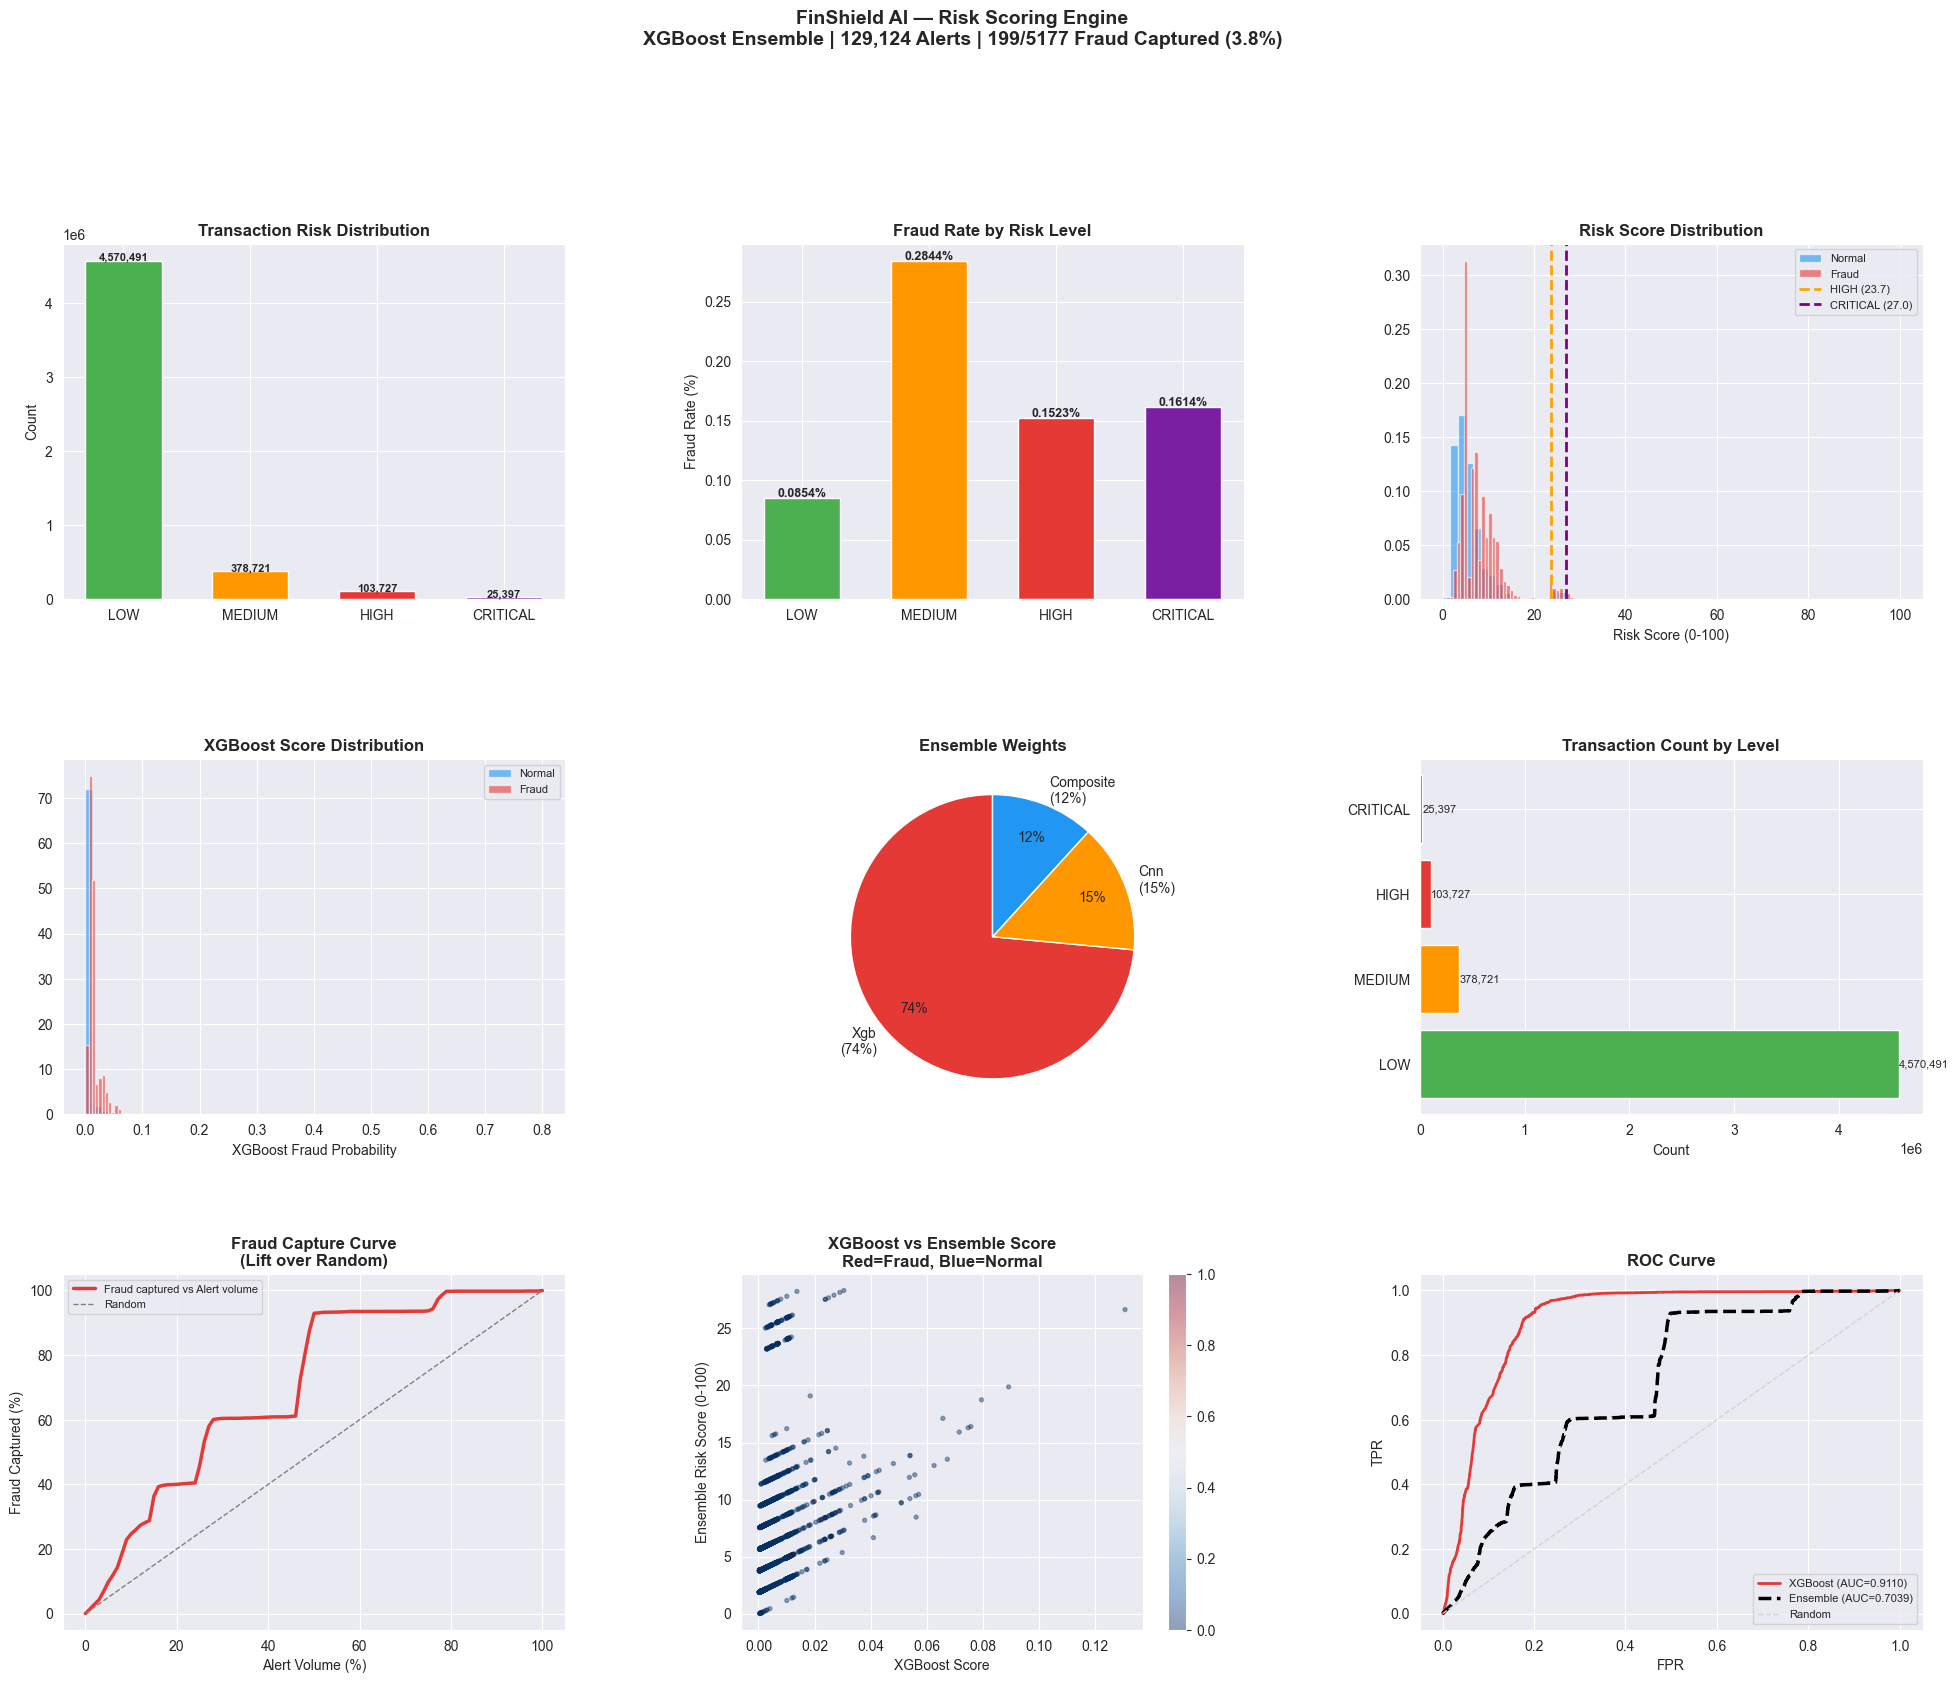

Charts saved!


In [11]:
fig = plt.figure(figsize=(24, 18))
fig.suptitle(
    f'FinShield AI — Risk Scoring Engine\n'
    f'XGBoost Ensemble | {len(alerts):,} Alerts | '
    f'{fraud_in_alerts}/{total_fraud} Fraud Captured ({capture_rate:.1f}%)',
    fontsize=14, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

colors_risk = {
    'LOW':'#4CAF50', 'MEDIUM':'#FF9800',
    'HIGH':'#E53935', 'CRITICAL':'#7B1FA2'
}
level_order = ['LOW','MEDIUM','HIGH','CRITICAL']

# Chart 1: Risk level distribution
ax1 = fig.add_subplot(gs[0,0])
cnts  = risk_df['risk_level'].value_counts()
bars1 = ax1.bar(
    [l for l in level_order if l in cnts],
    [cnts.get(l,0) for l in level_order if l in cnts],
    color=[colors_risk[l] for l in level_order if l in cnts],
    edgecolor='white', width=0.6
)
ax1.set_title('Transaction Risk Distribution', fontweight='bold')
ax1.set_ylabel('Count')
for bar in bars1:
    ax1.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+5000,
        f'{int(bar.get_height()):,}',
        ha='center', fontsize=8, fontweight='bold'
    )

# Chart 2: Fraud rate by risk level
ax2 = fig.add_subplot(gs[0,1])
fraud_rates = [
    risk_df[risk_df['risk_level']==l]['Is Laundering'].mean()*100
    for l in level_order
]
bars2 = ax2.bar(
    level_order, fraud_rates,
    color=[colors_risk[l] for l in level_order],
    edgecolor='white', width=0.6
)
ax2.set_title('Fraud Rate by Risk Level', fontweight='bold')
ax2.set_ylabel('Fraud Rate (%)')
for bar, rate in zip(bars2, fraud_rates):
    ax2.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.001,
        f'{rate:.4f}%', ha='center', fontweight='bold', fontsize=9
    )

# Chart 3: Risk score distribution (fraud vs normal)
ax3 = fig.add_subplot(gs[0,2])
ax3.hist(
    risk_df[risk_df['Is Laundering']==0]['risk_score_100'],
    bins=60, color='#2196F3', alpha=0.6, label='Normal', density=True
)
ax3.hist(
    risk_df[risk_df['Is Laundering']==1]['risk_score_100'],
    bins=60, color='#E53935', alpha=0.6, label='Fraud',  density=True
)
ax3.axvline(THRESH_HIGH,     color='orange', linestyle='--', linewidth=2, label=f'HIGH ({THRESH_HIGH:.1f})')
ax3.axvline(THRESH_CRITICAL, color='purple', linestyle='--', linewidth=2, label=f'CRITICAL ({THRESH_CRITICAL:.1f})')
ax3.set_title('Risk Score Distribution', fontweight='bold')
ax3.set_xlabel('Risk Score (0-100)')
ax3.legend(fontsize=8)

# Chart 4: XGBoost score distribution
ax4 = fig.add_subplot(gs[1,0])
ax4.hist(
    risk_df[risk_df['Is Laundering']==0]['xgb_score'],
    bins=60, color='#2196F3', alpha=0.6, label='Normal', density=True
)
ax4.hist(
    risk_df[risk_df['Is Laundering']==1]['xgb_score'],
    bins=60, color='#E53935', alpha=0.6, label='Fraud',  density=True
)
ax4.set_title('XGBoost Score Distribution', fontweight='bold')
ax4.set_xlabel('XGBoost Fraud Probability')
ax4.legend(fontsize=8)

# Chart 5: Model weights pie
ax5 = fig.add_subplot(gs[1,1])
active_w = {k: v for k, v in WEIGHTS.items() if v > 0}
ax5.pie(
    list(active_w.values()),
    labels=[f"{k.replace('_score','').replace('_',' ').title()}\n({v*100:.0f}%)"
            for k,v in active_w.items()],
    colors=['#E53935','#FF9800','#2196F3','#9C27B0','#4CAF50','#795548'][:len(active_w)],
    autopct='%1.0f%%', startangle=90, pctdistance=0.75
)
ax5.set_title('Ensemble Weights', fontweight='bold')

# Chart 6: Alert volume
ax6 = fig.add_subplot(gs[1,2])
alert_cnts = {l: len(risk_df[risk_df['risk_level']==l]) for l in level_order}
ax6.barh(
    level_order,
    [alert_cnts[l] for l in level_order],
    color=[colors_risk[l] for l in level_order],
    edgecolor='white'
)
ax6.set_title('Transaction Count by Level', fontweight='bold')
ax6.set_xlabel('Count')
for i, (l, cnt) in enumerate(alert_cnts.items()):
    ax6.text(cnt + 500, i, f'{cnt:,}', va='center', fontsize=8)

# Chart 7: Fraud capture curve
ax7 = fig.add_subplot(gs[2,0])
pcts          = np.arange(0, 101, 1)
thresholds_pct= np.percentile(risk_df['risk_score_100'], pcts)
capture_curve = []
alert_curve   = []
for t in thresholds_pct[::-1]:
    flagged     = risk_df[risk_df['risk_score_100'] >= t]
    cap         = flagged['Is Laundering'].sum() / max(total_fraud, 1) * 100
    alt         = len(flagged) / len(risk_df) * 100
    capture_curve.append(cap)
    alert_curve.append(alt)

ax7.plot(alert_curve, capture_curve, color='#E53935', linewidth=2.5,
         label='Fraud captured vs Alert volume')
ax7.plot([0,100],[0,100], '--', color='gray', linewidth=1, label='Random')
ax7.set_title('Fraud Capture Curve\n(Lift over Random)', fontweight='bold')
ax7.set_xlabel('Alert Volume (%)')
ax7.set_ylabel('Fraud Captured (%)')
ax7.legend(fontsize=8)

# Chart 8: XGBoost vs Ensemble scatter
ax8 = fig.add_subplot(gs[2,1])
n_samp    = min(5000, len(risk_df))
samp_idx  = np.random.choice(len(risk_df), n_samp, replace=False)
samp_data = risk_df.iloc[samp_idx]
sc = ax8.scatter(
    samp_data['xgb_score'],
    samp_data['risk_score_100'],
    c=samp_data['Is Laundering'],
    cmap='RdBu_r', alpha=0.4, s=8,
    vmin=0, vmax=1
)
ax8.set_title('XGBoost vs Ensemble Score\nRed=Fraud, Blue=Normal', fontweight='bold')
ax8.set_xlabel('XGBoost Score')
ax8.set_ylabel('Ensemble Risk Score (0-100)')
plt.colorbar(sc, ax=ax8)

# Chart 9: ROC curve
ax9 = fig.add_subplot(gs[2,2])
fpr_x, tpr_x, _ = roc_curve(y_all, risk_df['xgb_score'])
fpr_e, tpr_e, _ = roc_curve(y_all, risk_df['risk_score_100'])
auc_x = roc_auc_score(y_all, risk_df['xgb_score'])
auc_e = roc_auc_score(y_all, risk_df['risk_score_100'])
ax9.plot(fpr_x, tpr_x, color='#E53935', linewidth=2,
         label=f'XGBoost (AUC={auc_x:.4f})')
ax9.plot(fpr_e, tpr_e, color='black', linewidth=2.5, linestyle='--',
         label=f'Ensemble (AUC={auc_e:.4f})')
ax9.plot([0,1],[0,1],'--', color='lightgray', linewidth=1, label='Random')
ax9.set_title('ROC Curve', fontweight='bold')
ax9.set_xlabel('FPR'); ax9.set_ylabel('TPR')
ax9.legend(fontsize=8)

plt.savefig('risk_engine_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")

## Save everything

In [12]:
os.makedirs('results', exist_ok=True)
os.makedirs('models',  exist_ok=True)

# Save full risk scores
risk_df.to_csv('results/final_risk_scores.csv', index=False)
print(f"Saved: results/final_risk_scores.csv ({len(risk_df):,} rows)")

# Save alerts
alerts.to_csv('results/alerts.csv', index=False)
print(f"Saved: results/alerts.csv ({len(alerts):,} alerts)")

# Save risk engine config (Flask API loads this)
risk_config = {
    'weights'            : WEIGHTS,
    'thresholds'         : {
        'CRITICAL': float(THRESH_CRITICAL),
        'HIGH'    : float(THRESH_HIGH),
        'MEDIUM'  : float(THRESH_MEDIUM),
        'LOW'     : 0.0
    },
    'total_transactions' : int(len(risk_df)),
    'total_alerts'       : int(len(alerts)),
    'fraud_captured'     : int(fraud_in_alerts),
    'total_fraud'        : int(total_fraud),
    'capture_rate_pct'   : round(capture_rate, 2),
    'alert_rate_pct'     : round(alert_rate, 2),
    'active_models'      : [col for col, w in WEIGHTS.items() if w > 0],
    'xgb_features'       : XGB_FEATURES,
    'auc_xgb'            : round(auc_x, 4),
    'auc_ensemble'       : round(auc_e, 4),
}
joblib.dump(risk_config, 'models/risk_engine_config.pkl')
print(f"Saved: models/risk_engine_config.pkl")

Saved: results/final_risk_scores.csv (5,078,336 rows)
Saved: results/alerts.csv (129,124 alerts)
Saved: models/risk_engine_config.pkl


## Final summary

In [13]:
print("=" * 60)
print("RISK SCORING ENGINE — COMPLETE")
print("=" * 60)

print(f"""
ACTIVE MODELS AND WEIGHTS
{chr(10).join(f"  {col.replace('_score',''):15}: {w:.3f} ({w*100:.1f}%)"
              for col, w in WEIGHTS.items() if w > 0)}

PERFORMANCE
  XGBoost AUC-ROC   : {auc_x:.4f}
  Ensemble AUC-ROC  : {auc_e:.4f}

CALIBRATED THRESHOLDS (from actual score distribution)
  CRITICAL >= {THRESH_CRITICAL:.2f}  (top 0.5% of all transactions)
  HIGH     >= {THRESH_HIGH:.2f}  (top 2.5%)
  MEDIUM   >= {THRESH_MEDIUM:.2f}  (top 10%)
  LOW         everything else

RISK DISTRIBUTION
  CRITICAL : {(risk_df['risk_level']=='CRITICAL').sum():>10,} ({(risk_df['risk_level']=='CRITICAL').mean()*100:.2f}%)
  HIGH     : {(risk_df['risk_level']=='HIGH').sum():>10,} ({(risk_df['risk_level']=='HIGH').mean()*100:.2f}%)
  MEDIUM   : {(risk_df['risk_level']=='MEDIUM').sum():>10,} ({(risk_df['risk_level']=='MEDIUM').mean()*100:.2f}%)
  LOW      : {(risk_df['risk_level']=='LOW').sum():>10,} ({(risk_df['risk_level']=='LOW').mean()*100:.2f}%)

ALERTS
  Total generated    : {len(alerts):,} ({alert_rate:.2f}% of all transactions)
  Fraud captured     : {fraud_in_alerts:,} / {total_fraud:,}
  Capture rate       : {capture_rate:.2f}%

FILES SAVED
  results/final_risk_scores.csv  ({len(risk_df):,} rows)
  results/alerts.csv             ({len(alerts):,} alerts)
  models/risk_engine_config.pkl

NEXT → Flask API + Dashboard
""")

RISK SCORING ENGINE — COMPLETE

ACTIVE MODELS AND WEIGHTS
  xgb            : 0.735 (73.5%)
  cnn            : 0.147 (14.7%)
  composite      : 0.118 (11.8%)

PERFORMANCE
  XGBoost AUC-ROC   : 0.9110
  Ensemble AUC-ROC  : 0.7039

CALIBRATED THRESHOLDS (from actual score distribution)
  CRITICAL >= 27.00  (top 0.5% of all transactions)
  HIGH     >= 23.66  (top 2.5%)
  MEDIUM   >= 10.13  (top 10%)
  LOW         everything else

RISK DISTRIBUTION
  CRITICAL :     25,397 (0.50%)
  HIGH     :    103,727 (2.04%)
  MEDIUM   :    378,721 (7.46%)
  LOW      :  4,570,491 (90.00%)

ALERTS
  Total generated    : 129,124 (2.54% of all transactions)
  Fraud captured     : 199 / 5,177
  Capture rate       : 3.84%

FILES SAVED
  results/final_risk_scores.csv  (5,078,336 rows)
  results/alerts.csv             (129,124 alerts)
  models/risk_engine_config.pkl

NEXT → Flask API + Dashboard

